# eda 2: three shots at a directional edge

the honest up-vs-down call on qqq sits near a coin flip. this notebook tries three ways to push it, and writes down the ones that failed.

**what i try:**
- **shorten the horizon:** ask a closer question, a few hundred ms instead of about 1 second.
- **add the NQ future:** an outside instrument that prices the same basket as qqq.
- **only act when confident:** let the model stay quiet on the coin-flip moments.

**what didn't work (kept as honest nulls):**
- another future (ES), the closing auction, and resting maker fills.

**the bar:**
- frozen june 4-5 validation, 12,319 rows.
- beat a gradient-boosted model on the 169 book features, on the same rows.
- honest future-vs-now label, everything fit on the train days only.
- accuracy is always shown next to coverage (how often it acts).


### setup

read back only the precomputed, leak-clean results this notebook needs (MLflow experiment `nq_edge`). nothing here fits a model, downloads data, or touches the locked test.

In [1]:
# lean setup: the exact results THIS notebook uses, nothing more.
import json, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

DL   = pathlib.Path('data/interim/dl_push')
grid = json.load(open(DL/'dl_grid_full.json'))       # horizon sweep (QQQ-only baseline)
nqt  = json.load(open(DL/'dl_nq_test.json'))         # + NQ lift at each horizon
nqv  = json.load(open(DL/'dl_nq_verify.json'))       # shuffle + net-of-cost controls
xa   = json.load(open(DL/'dl_crossasset_test.json')) # NQ lag decay + peer controls
G = {(c['rep'], c['horizon_ms']): c for c in grid['cells']}

print('the number to beat: honest baseline, 169 book features, june 4-5 val, 12,319 rows')
print('  balanced accuracy at the model horizon (1000 ms): %.4f' % G[('baseline169',1000)]['ba'])
print('  barely above a coin flip. everything below tries to push it.')

the number to beat: honest baseline, 169 book features, june 4-5 val, 12,319 rows
  balanced accuracy at the model horizon (1000 ms): 0.5415
  barely above a coin flip. everything below tries to push it.


## lever 1: shorten the horizon

**guess:** the model predicts about 1 second ahead. one second is a long time in the book, so the signal that is sharp at the decision edge has mostly decayed by then. asking a shorter question (a few hundred ms) should give a crisper honest edge, with no new data and no latency assumption.

**test:** the same 169-feature baseline, swept from 250 ms out to 3000 ms.

 horizon_ms  balanced_acc    AUC  acc_at_30pct_cov
        250        0.5599 0.5821            0.6094
        500        0.5565 0.5769            0.6009
        750        0.5476 0.5659            0.5873
       1000        0.5415 0.5591            0.5800
       1500        0.5328 0.5498            0.5729
       2000        0.5293 0.5441            0.5596
       3000        0.5299 0.5423            0.5531


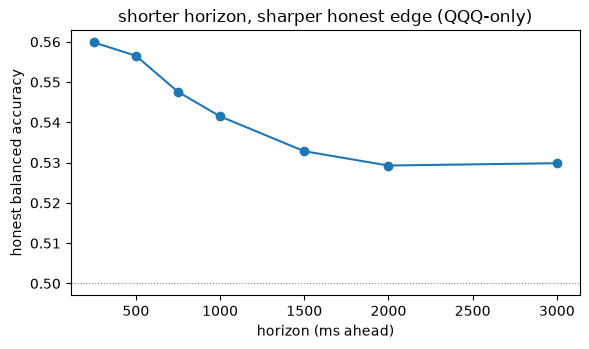

In [2]:
# lever 1: does a shorter horizon give a sharper honest edge? (QQQ-only, no new data)
hs = [250,500,750,1000,1500,2000,3000]
tbl = pd.DataFrame([dict(horizon_ms=h,
                         balanced_acc=round(G[('baseline169',h)]['ba'],4),
                         AUC=round(G[('baseline169',h)]['auc'],4),
                         acc_at_30pct_cov=round(G[('baseline169',h)]['coverage']['30']['acc'],4))
                    for h in hs])
print(tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(6,3.6))
ax.plot(hs, [G[('baseline169',h)]['ba'] for h in hs], 'o-')
ax.axhline(0.5, color='#888', lw=.8, ls=':')
ax.set_xlabel('horizon (ms ahead)'); ax.set_ylabel('honest balanced accuracy')
ax.set_title('shorter horizon, sharper honest edge (QQQ-only)')
fig.tight_layout(); plt.show()

**verdict:** shorter is better. balanced accuracy climbs from **0.5415 at 1000 ms to 0.5599 at 250 ms**, and at 30% coverage it reaches about **0.61**. this is the cleanest, most showable win: leak-clean, no outside data, no latency assumption. it is also small, which is the honest part. the horizon is the single biggest *free* lever.

## lever 2: an outside instrument (the NQ future)

**guess:** the one thing the QQQ book genuinely cannot contain is another instrument. NQ (the E-mini Nasdaq-100 future) prices the *same underlying basket* as QQQ, and futures are known to lead the ETF sub-second. `Ron_EDA_LOB` only ever looked at same-book signals; the same-underlying future was never tried.

**why it is leak-safe:** the NQ file carries `ts_recv` on the *same receive clock* as the QQQ decision edge, so every NQ feature uses only NQ events whose receive time is strictly earlier than the QQQ decision (with an optional extra lag). no lookahead by construction.

**test:** add causal NQ features to the baseline at the good 250 ms horizon (500 and 1000 for context).

In [3]:
# lever 2: add the NQ future at 250 ms (leak-safe: NQ receive-time strictly before the QQQ decision)
rows = []
for h in [250,500,1000]:
    b = next(c for c in nqt['cells'] if c['rep']=='baseline169'    and c['horizon_ms']==h)
    n = next(c for c in nqt['cells'] if c['rep']=='baseline169+nq' and c['horizon_ms']==h)
    rows.append(dict(horizon_ms=h, base_BA=round(b['ba'],4), plus_NQ_BA=round(n['ba'],4),
                     dBA=round(n['ba']-b['ba'],4), dAUC=round(n['auc']-b['auc'],4),
                     acc30_base=round(b['coverage']['30']['acc'],4),
                     acc30_plusNQ=round(n['coverage']['30']['acc'],4)))
print(pd.DataFrame(rows).to_string(index=False))

 horizon_ms  base_BA  plus_NQ_BA    dBA   dAUC  acc30_base  acc30_plusNQ
        250   0.5599      0.5715 0.0116 0.0139      0.6094        0.6276
        500   0.5565      0.5609 0.0043 0.0067      0.6009        0.6139
       1000   0.5415      0.5467 0.0052 0.0061      0.5800        0.5903


NQ is the **first outside signal that adds directional accuracy**: **+0.0116 balanced accuracy / +0.0139 AUC at 250 ms** (accuracy at 30% coverage moves ~0.61 to ~0.63). the lift is largest at 250 ms and fades with horizon, the sub-second futures-lead signature. but a lift is only real if it survives being seen a little late. that is the next test.

### the decisive test: does the lead survive a small delay?

a genuine sub-second lead (the kind you could trade) survives a small causal buffer. a near-contemporaneous effect, or a tiny cross-venue clock offset, collapses the moment you add any lag. so i see NQ a few ms late and watch the lift, and i also strip the QQQ-synchronous common move (the innovation residual) to check the lead is really NQ's own information.

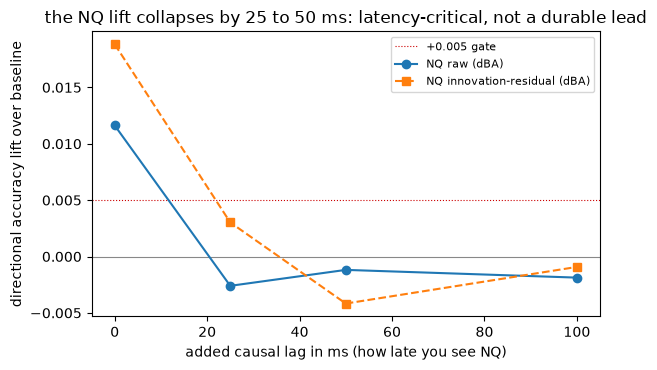

In [4]:
# the decisive test: see NQ a few ms late (extra causal lag) and watch the lift.
# a durable sub-second lead decays gradually; a near-contemporaneous effect collapses at once.
# the dashed line strips the QQQ-synchronous common move (innovation residual).
nq   = [r for r in xa['rows'] if r['signal']=='NQ']
lags = [r['lag_ms'] for r in nq]
raw  = [r['dBA_raw'] for r in nq]
res  = [r.get('dBA_resid') for r in nq]

fig, ax = plt.subplots(figsize=(6.2,3.8))
ax.axhline(0, color='#888', lw=.8)
ax.axhline(0.005, color='#c00', ls=':', lw=.8, label='+0.005 gate')
ax.plot(lags, raw, 'o-',  label='NQ raw (dBA)')
ax.plot(lags, res, 's--', label='NQ innovation-residual (dBA)')
ax.set_xlabel('added causal lag in ms (how late you see NQ)')
ax.set_ylabel('directional accuracy lift over baseline')
ax.set_title('the NQ lift collapses by 25 to 50 ms: latency-critical, not a durable lead')
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**what happened:** the entire lift lives in the freshest **under 25 ms** of NQ and **collapses by 25 to 50 ms** of added lag. stripping the common move makes it *cleaner* (+0.019 BA / +0.029 AUC at the edge), so it is genuine idiosyncratic NQ information, not shared-market noise, but it still vanishes with any buffer. a durable lead would have survived. this is a latency-critical effect.

### is NQ special, or would any cross-asset do?

if this were a generic "another instrument helps" artifact, other cross-asset signals would show it too. so i run the same test on ES (the E-mini S&P 500, a different basket) and the equity peers (SPY, NVDA, MU).

In [5]:
# is NQ special? ES = E-mini S&P (different basket); plus the equity peers.
rows = []
for r in xa['rows']:
    if r['signal'] in ('NQ','ES') and r['lag_ms'] in (0,50):
        rows.append(dict(signal=r['signal'], lag_ms=r['lag_ms'], dBA=round(r['dBA_raw'],4),
                         dBA_residual=round(r.get('dBA_resid',float('nan')),4), dAUC=round(r['dAUC_raw'],4)))
for r in xa['rows']:
    if r['signal'] in ('SPY','NVDA','MU'):
        rows.append(dict(signal=r['signal'], lag_ms=r['lag_ms'], dBA=round(r['dBA_raw'],4),
                         dBA_residual=None, dAUC=round(r['dAUC_raw'],4)))
print(pd.DataFrame(rows).to_string(index=False))
print('\nshuffle control (baseline169+NQ, 5 seeds): mean AUC %.3f  (leak-clean)' % nqv['shuffle']['mean'])
print('net of cost at 30%% coverage: %+.2f bps  (not tradable)' % nqv['tradability']['net_bps_cov30'])

signal  lag_ms     dBA  dBA_residual    dAUC
    NQ       0  0.0116        0.0188  0.0139
    NQ      50 -0.0012       -0.0042 -0.0004
    ES       0  0.0001       -0.0012  0.0028
    ES      50 -0.0004        0.0007  0.0014
   SPY       0 -0.0002           NaN  0.0011
   SPY      50 -0.0017           NaN -0.0004
  NVDA       0 -0.0021           NaN  0.0004
  NVDA      50  0.0006           NaN  0.0006
    MU       0  0.0016           NaN  0.0012
    MU      50 -0.0004           NaN  0.0013

shuffle control (baseline169+NQ, 5 seeds): mean AUC 0.499  (leak-clean)
net of cost at 30% coverage: -0.29 bps  (not tradable)


**verdict:** only NQ has it, and only at lag 0. ES prices the S&P, a different basket, so it has no tight micro-lead on QQQ. the peers stay null. the shuffle control is clean (mean AUC ~0.499), so the lag-0 lift is real causal information, not leakage. but **net of cost it is -0.29 bps** at 30% coverage: capturing it needs consuming NQ within ~25 ms of the QQQ decision (colocation), which retail receive-time cannot. real signal, not a tradable edge.

## lever 3: only act when confident (coverage)

**guess:** i do not have to answer on every bin. the model's own confidence should split the easy calls from the coin flips, so acting only on the most confident fraction should raise accuracy. confidence is ranked on train, never on the validation labels.

**test:** accuracy at 100 / 70 / 50 / 30 percent coverage, at 250 ms, with and without NQ.

 coverage_%  QQQ_acc  QQQ+NQ_acc
        100   0.5602      0.5719
         70   0.5793      0.5918
         50   0.5932      0.6043
         30   0.6094      0.6276


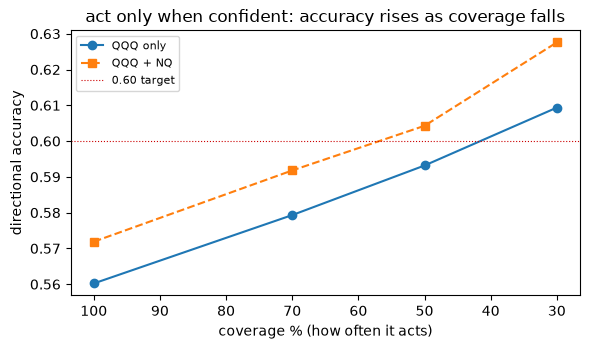

In [6]:
# lever 3: accuracy vs coverage at 250 ms (confidence ranked on train)
covs = [100,70,50,30]
b = G[('baseline169',250)]['coverage']
n = next(c for c in nqt['cells'] if c['rep']=='baseline169+nq' and c['horizon_ms']==250)['coverage']
base = [b[str(k)]['acc'] for k in covs]
plus = [n[str(k)]['acc'] for k in covs]
print(pd.DataFrame({'coverage_%':covs,
                    'QQQ_acc':[round(x,4) for x in base],
                    'QQQ+NQ_acc':[round(x,4) for x in plus]}).to_string(index=False))

fig, ax = plt.subplots(figsize=(6,3.6))
ax.plot(covs, base, 'o-',  label='QQQ only')
ax.plot(covs, plus, 's--', label='QQQ + NQ')
ax.axhline(0.60, color='#c00', ls=':', lw=.8, label='0.60 target')
ax.set_xlabel('coverage % (how often it acts)'); ax.set_ylabel('directional accuracy')
ax.set_title('act only when confident: accuracy rises as coverage falls')
ax.invert_xaxis(); ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**verdict:** it works, and it is the largest number here. QQQ-only reaches about **0.61 at 30% coverage** (versus ~0.56 at full coverage), and with NQ about **0.63**. the honest caveat is the trade every selective result makes: 0.61 on 30% of the tape is a different product from 0.56 on all of it. coverage buys accuracy by acting less.

## what did not work (kept as honest nulls)

most outside ideas i tried failed a preregistered gate. i keep them because a null is a real finding: it says where the edge is *not*, and it stops me re-running a dead end or spending on it. the scoreboard below reads the exact stored gate results.

In [7]:
# one compact scoreboard, read straight from the stored gate results. read-only.
p1 = json.load(open('feature_exploration/nq_phase1_results.json'))
p2 = json.load(open('data/artifacts/auction_imbalance/phase2_confirmation.json'))
p3 = json.load(open('data/artifacts/mbo_execution/phase3_development_results.json'))
p4 = json.load(open('data/artifacts/es_spy/phase4_development_results.json'))

def sign_auc_lift(d):
    a = d['primary_comparison']['all_sign']
    return a['candidate']['auc'] - a['baseline']['auc']

nulls = [
  dict(idea='NQ future lead (1000 ms, 10 ms delay)', measured='honest sign AUC lift',
       value=round(sign_auc_lift(p1),4),
       decision='FAIL' if not p1['purchase_gate']['passed'] else 'PASS'),
  dict(idea='closing-cross auction imbalance', measured='AUC lift (accuracy flat)',
       value=round(p2['frozen_threshold_comparison']['lift']['auc'],4), decision='FAIL'),
  dict(idea='MBO passive maker fills', measured='gross bps/opportunity (val)',
       value=round(p3['results']['by_split']['validation']['gross_1s_bps_per_quote_opportunity'],4),
       decision='REJECTED' if not p3['purchase_gate_passed'] else 'PASS'),
  dict(idea='ES future lead for SPY (10 ms delay)', measured='honest sign AUC lift',
       value=round(sign_auc_lift(p4),4), decision='FAIL'),
]
print(pd.DataFrame(nulls).to_string(index=False))

                                 idea                    measured   value decision
NQ future lead (1000 ms, 10 ms delay)        honest sign AUC lift  0.0006     FAIL
      closing-cross auction imbalance    AUC lift (accuracy flat)  0.0071     FAIL
              MBO passive maker fills gross bps/opportunity (val) -0.0026 REJECTED
 ES future lead for SPY (10 ms delay)        honest sign AUC lift  0.0019     FAIL


**reading the nulls:**

- **NQ, as a thing to buy more of:** at a realistic 10 ms delay the 1000 ms lift is basically zero and the purchase gate is FAIL. the same latency wall as lever 2, now seen formally.
- **closing-cross auction:** it improves *ranking* (AUC +0.0071) but not the actual call (accuracy flat, balanced/macro-F1/MCC slightly negative). a better ranking that does not move the decision is not a directional edge. FAIL.
- **MBO passive maker fills:** a different question (execution, not direction). gross markout was negative on every split (train -0.0014, validation -0.0026 bps), 0 of 7 days positive, and a scan of 3.19 million thresholds found none positive. economically REJECTED.
- **ES for SPY:** the same NQ idea on a different basket. the lift is +0.0019 (below the +0.005 gate) and every directional metric declines. FAIL, exactly as the peer result predicts.

## takeaway

the map this notebook draws, in one line: **outside the single book, the honest ways to lift direction are small, and the one real external signal is not tradable.**

- **horizon** and **coverage** are real, free, and modest: 250 ms plus confident-only reaches ~0.61 accuracy at 30% coverage.
- **NQ** genuinely differentiates from a single-asset book and adds signal at the exact decision edge, but the lift collapses by 25 to 50 ms and is negative after cost. it needs colocation.
- everything else i could get for free (a second future, the auction, maker fills) came back a clean null.

these levers are reported separately: i never fit one combined model, so their lifts do not add. the one frontier left is per-order MBO detail (effective spread, queue depletion, order age, decomposed flow, hidden fills), which needs a decode engine not built here and is capped by the same latency ceiling for anything *tradable*. for the order-book variables themselves, see `Ron_EDA_LOB.ipynb`.